# Split-half phenotype reliability

This notebook measures the stability of participant phenotype estimates across non-overlapping meal subsets from the same participants. Half-specific models share scaling constants, and score reliability is evaluated in a common PC basis derived from the full free-living-data fit.

## Notebook flow

1. Define the shared scaling and fit the full-data reference model.
2. Construct odd/even and chronological meal halves and fit MMER-XGBoost separately to each half.
3. Compare half-specific covariance spectra and PC-axis alignment.
4. Project half-specific BLUPs into the shared reference basis and estimate PC1/PC2 agreement.
5. Export covariance-spectrum and reliability tables and generate the split-half figure.

## Outputs

CSV files written to `Results/`:

| File | Contents |
| --- | --- |
| `half_sample_covariance_spectrum_summary.csv` | Covariance eigenvalues, variance shares, and cumulative shares for each half. |
| `split_half_pca_reliability_by_design.csv` | PC-score ICCs and correlations for odd/even and chronological splits. |

The score-comparison figure is saved as `Figures/panel_3_PC1_PC2_split_half.svg`.

## 1. Setup

Resolve project paths, import the split-half utilities, and load the common prepared meal-level dataset.

In [1]:
from pathlib import Path
import sys

# Find the project when launched from its root, code/, or a notebook subfolder.
for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    CODE_DIR = PROJECT_ROOT / "code"
    if (CODE_DIR / "data_paths.py").is_file():
        break
else:
    raise FileNotFoundError("Open this notebook from within the project directory.")

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# Shared defaults; override individual paths here if needed.
from data_paths import DATA_DIR, METADATA_PATH, MEAL_DATA_PATH, CGM_METRICS_PATH
FIGURES_DIR = PROJECT_ROOT / "Figures"
RESULTS_DIR = PROJECT_ROOT / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import xgboost as xgb
from mmer import MixedEffectEstimator
from sklearn.model_selection import BaseCrossValidator, GroupKFold
from tqdm import tqdm

In [3]:
from utils import (
    build_design_mats,
    load_and_prepare_data,
    make_xgb,
    split_half_within_subject,
)

In [4]:
meta_data, data, id_to_subject_key, clusters= load_and_prepare_data(
    METADATA_PATH,
    MEAL_DATA_PATH,
)

print(f"Prepared {len(data):,} meals from {data['subject_key'].nunique():,} participants.")

data shape : (54987, 133)
Prepared 54,987 meals from 992 participants.


## 2. Shared reference fit and half-specific models

In [5]:
import pingouin as pg
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler
# SETTINGS

feature_cols = ["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten"]

prediction_metrics = [
    "max_glucose",
    "peak_duration",
    "end_glucose",
    "positive_iAUC",
]

rename_blups = {
    "intercept": "intercept",
    "carb_eaten": "carb",
    "fat_eaten": "fat",
    "protein_eaten": "protein",
    "fiber_eaten": "fiber",
    0: "intercept",
    1: "carb",
    2: "fat",
    3: "protein",
    4: "fiber",
}

effects = ["intercept", "carb", "fat", "protein", "fiber"]

def _scalar(x):
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return x[0]
    return x

def get_code_to_subject(cluster_mapping, codes):
    cm = cluster_mapping
    codes = list(codes)

    if isinstance(cm, dict):
        if set(codes).issubset(cm.keys()):
            return {k: _scalar(v) for k, v in cm.items()}
        else:
            return {_scalar(v): k for k, v in cm.items()}

    elif isinstance(cm, pd.Series):
        if set(codes).issubset(cm.index):
            return {k: _scalar(v) for k, v in cm.items()}
        else:
            return {_scalar(v): k for k, v in cm.items()}

    elif isinstance(cm, pd.DataFrame):
        code_col = next(c for c in cm.columns if set(cm[c].dropna()).issuperset(set(codes)))
        key_col = next(c for c in cm.columns if c != code_col)
        return {
            _scalar(code): _scalar(key)
            for code, key in zip(cm[code_col], cm[key_col])
        }

    else:
        arr = np.asarray(cm, dtype=object)

        if arr.ndim == 1:
            return {i: _scalar(v) for i, v in enumerate(arr)}

        arr = arr.reshape(arr.shape[0], -1)[:, :2]
        return {
            _scalar(code): _scalar(key)
            for code, key in arr
        }

# DATA PREP

data["eaten_date"] = pd.to_datetime(data["eaten_date"])

# global scalers fitted ONCE on full analysis data
feature_scaler = StandardScaler().fit(data[feature_cols])
outcome_scaler = StandardScaler().fit(data[prediction_metrics])

# SPLIT HALF WITHIN SUBJECT
# alternating meals after date-sort
half_A_odd_even, half_B_odd_even, span = split_half_within_subject(data, split_mode="even_odd") # temporal

half_A_odd_temporal, half_B_temporal, span = split_half_within_subject(data, split_mode="temporal") # temporal



# Use full-data scalers to keep both halves in the same units.

prediction_metrics = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC"]

_, _, _, _, _, _, _, _, _, info_ref, _, _ = \
    build_design_mats(
        data,
        full_train=True,
        target_outcome=prediction_metrics,
        apply_mundlak=False,
        use_interactions=[False],
        population_z_scoring_features=True,
        remove_std_meals_from_training=True,
        remove_features=["demographics"],
        random_slopes=["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten"],
        population_z_scoring_outcome=True,
    )
fixed_scalers = {
    "z_score_mean": info_ref["z_score_mean"],
    "z_score_std": info_ref["z_score_std"],
    "outcome_mean": info_ref["outcome_mean"],
    "outcome_std": info_ref["outcome_std"],
}

if "other_mean" in info_ref:
    fixed_scalers["other_mean"] = info_ref["other_mean"]
    fixed_scalers["other_std"] = info_ref["other_std"]
    
# FIT + EXTRACT BLUPS
def fit_half_and_get_blups(df, label, fixed_scalers):
    # ---------- Build design matrices ----------
    (
        X, _, Z, _, y, _, clusters, _,
        cluster_mapping, info_, _, validation_dataframe
    ) = build_design_mats(
        df,
        full_train=True,
        target_outcome=prediction_metrics,
        apply_mundlak=False,
        use_interactions=[False],
        population_z_scoring_features=True,
        population_z_scoring_outcome=True,
        remove_std_meals_from_training=True,
        remove_features=["demographics"],
        random_slopes=feature_cols,
        fixed_scalers=fixed_scalers
    )

    y_mmer = np.asarray(y)
    if y_mmer.ndim == 1:
        y_mmer = y_mmer[:, None]

    groups_mmer = clusters.to_numpy().reshape(-1, 1)

    # ---------- Fit ----------
    model = MixedEffectEstimator(
        make_xgb(njobs=12),
        max_iter=50,
        slq_steps=40,
        tol=1e-7,
        n_jobs=4,
    )

    fit_result = model.fit(
        X,
        y_mmer,
        groups_mmer,
        random_slopes=([0, 1, 2, 3],),
    )

    # ---------- Extract BLUPs ----------
    blups = fit_result.blups(
        X,
        y_mmer,
        groups_mmer,
        group_idx=0,
    ).copy()

    # ---------- Rename BLUP columns ----------
    # blups() emits columns in outcome-major, effect-minor order:
    #   R1_Intercept, R1_Slope 1..4, R2_Intercept, ... , R4_Slope 4
    # matching G[0] index order (idx = outcome*q + effect).
    # rename preserves order, so the renamed frame stays aligned with G.
    slope_names = ["carb", "fat", "protein", "fiber"]

    rename_dict = {}

    for i, outcome in enumerate(prediction_metrics, start=1):

        rename_dict[f"R{i}_Intercept"] = f"{outcome}_intercept"

        for j, slope in enumerate(slope_names, start=1):
            rename_dict[f"R{i}_Slope {j}"] = f"{outcome}_{slope}"

    blups.rename(columns=rename_dict, inplace=True)

    # ---------- Map subject codes back to subject_key ----------
    code_to_subject = get_code_to_subject(cluster_mapping, blups.index)

    blups["subject_key"] = (
        blups.index.to_series()
        .map(code_to_subject)
        .map(_scalar)
        .values
    )

    # ---------- Reorder columns ----------
    effect_cols = [c for c in blups.columns if c != "subject_key"]

    blups = (
        blups.reset_index(drop=True)
             .loc[:, ["subject_key"] + effect_cols]
    )

    blups["half"] = label

    return blups, fit_result

In [6]:
##### get full data fit
import xgboost as xgb
from mmer import MixedEffectEstimator

groups = clusters.to_numpy()

results_list = []

prediction_metrics = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC",
                     ]
print("Dataset size:", data.shape)

print("Build the design matrix....")
X_train, _, Z_train, _, y_train, _, clusters_train, _, cluster_mapping, info_, _, validation_dataframe = \
    build_design_mats(
        data,
        full_train=True,
        target_outcome=prediction_metrics,
        apply_mundlak=False,
        use_interactions=[False],
        population_z_scoring_features=True,
        remove_std_meals_from_training=True,
        remove_features=["demographics"],
        random_slopes=["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten"],
        population_z_scoring_outcome=True,
    )

print("Train the model...")
xgb_fe = make_xgb(njobs=16)

final_model = MixedEffectEstimator(xgb_fe, max_iter=50, slq_steps=40, tol=1e-07, n_jobs=8)

groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
y_train_mmer = np.asarray(y_train)
if y_train_mmer.ndim == 1:
    y_train_mmer = y_train_mmer.reshape(-1, 1)

final_model = final_model.fit(X_train, y_train_mmer, groups_train_mmer,random_slopes=([0, 1, 2, 3],))

Dataset size: (54987, 133)
Build the design matrix....
Train the model...


Finished: no further improvement!:  66%|██████▌   | 33/50 06:14         


In [7]:
full_scalers = {
    "z_score_mean": info_["z_score_mean"],
    "z_score_std":  info_["z_score_std"],
    "other_mean":   info_.get("other_mean"),
    "other_std":    info_.get("other_std"),
    "outcome_mean": info_.get("outcome_mean"),
    "outcome_std":  info_.get("outcome_std"),
}
# RUN BOTH HALVES
### Odd / even split
half_A_odd_even, half_B_odd_even, span = split_half_within_subject(data, split_mode="even_odd") # temporal
blup_A_odd_even, model_A_result_odd_even = fit_half_and_get_blups(half_A_odd_even, "A", fixed_scalers)
blup_B_odd_even, model_B_result_odd_even = fit_half_and_get_blups(half_B_odd_even, "B", fixed_scalers)

# First half / second half
half_A_temporal, half_B_temporal, span = split_half_within_subject(data, split_mode="temporal") # temporal
blup_A_temporal, model_A_result_temporal = fit_half_and_get_blups(half_A_temporal, "A", fixed_scalers)
blup_B_temporal, model_B_result_temporal = fit_half_and_get_blups(half_B_temporal, "B", fixed_scalers)

Finished: no further improvement!:  56%|█████▌    | 28/50 04:21         
Finished: no further improvement!:  68%|██████▊   | 34/50 05:37         
Finished: no further improvement!:  68%|██████▊   | 34/50 04:56         
Finished: no further improvement!:  58%|█████▊    | 29/50 04:31         


## 3. Covariance and score reliability

The eigendecomposition and score-reliability analyses below compare odd/even and chronological halves.

In [8]:
import numpy as np
import pandas as pd

def summarize_G_spectrum(fit_result, label="model", n_pcs=5, save_path=None):
    """
    Minimal eigenvalue spectrum summary from MMER random-effect covariance.

    Uses:
        fit_result.G[0]

    Prints:
        - PC variance explained
        - cumulative variance explained
        - effective dimensionality
    """
    G = np.asarray(fit_result.G[0], dtype=float)

    # Remove numerical asymmetry.
    G = 0.5 * (G + G.T)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(G)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Remove tiny negative numerical artifacts
    eigvals[eigvals < 0] = 0

    total_var = eigvals.sum()
    var_exp = eigvals / total_var
    cum_var = np.cumsum(var_exp)

    # Effective dimensionality / participation ratio
    d_eff = total_var**2 / np.sum(eigvals**2)

    spectrum = pd.DataFrame({
        "label": label,
        "PC": np.arange(1, len(eigvals) + 1),
        "eigenvalue": eigvals,
        "variance_explained": var_exp,
        "cumulative_variance": cum_var,
    })

    print("\n" + "=" * 60)
    print(f"Spectrum: {label}")
    print("=" * 60)
    print(f"Effective dimensionality: {d_eff:.2f}")
    print(f"PC1 variance explained: {var_exp[0] * 100:.1f}%")
    print(f"PC1 + PC2 variance explained: {cum_var[1] * 100:.1f}%")

    print("\nLeading PCs:")
    print(
        spectrum.head(n_pcs).to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )

    if save_path is not None:
        spectrum.to_csv(save_path, index=False)
        print(f"\nSaved: {save_path}")

    return spectrum, eigvals, eigvecs, d_eff

spec_odd, eig_odd, vec_odd, deff_odd = summarize_G_spectrum(
    model_A_result_odd_even,
    label="odd",
    save_path=None
)

spec_even, eig_even, vec_even, deff_even = summarize_G_spectrum(
    model_B_result_odd_even,
    label="even",
    save_path=None
)

spec_temp_A, eig_temp_A, vec_temp_A, deff_temp_A = summarize_G_spectrum(
    model_A_result_temporal,
    label="temporal_first",
    save_path=None
)

spec_temp_B, eig_temp_B, vec_temp_B, deff_temp_B = summarize_G_spectrum(
    model_B_result_temporal,
    label="temporal_second",
    save_path=None
)


Spectrum: odd
Effective dimensionality: 2.40
PC1 variance explained: 62.6%
PC1 + PC2 variance explained: 73.5%

Leading PCs:
label  PC  eigenvalue  variance_explained  cumulative_variance
  odd   1      0.3710              0.6260               0.6260
  odd   2      0.0647              0.1092               0.7352
  odd   3      0.0464              0.0782               0.8134
  odd   4      0.0326              0.0549               0.8684
  odd   5      0.0266              0.0449               0.9132

Spectrum: even
Effective dimensionality: 2.30
PC1 variance explained: 64.1%
PC1 + PC2 variance explained: 75.9%

Leading PCs:
label  PC  eigenvalue  variance_explained  cumulative_variance
 even   1      0.4053              0.6406               0.6406
 even   2      0.0746              0.1180               0.7586
 even   3      0.0470              0.0743               0.8329
 even   4      0.0336              0.0531               0.8859
 even   5      0.0218              0.0344             

In [9]:
def combine_spectra(*spectra, save_path=None):
    """
    Combine multiple spectrum DataFrames into one DataFrame.

    Parameters
    ----------
    *spectra : pd.DataFrame
        Spectrum DataFrames returned by summarize_G_spectrum().
    save_path : str, optional
        If provided, saves the combined DataFrame as a CSV.

    Returns
    -------
    pd.DataFrame
        Combined spectrum DataFrame.
    """
    combined = pd.concat(spectra, ignore_index=True)

    if save_path is not None:
        combined.to_csv(save_path, index=False)
        print(f"Saved combined results to: {save_path}")

    return combined

all_spectra = combine_spectra(
    spec_odd,
    spec_even,
    spec_temp_A,
    spec_temp_B,
    save_path=RESULTS_DIR / "half_sample_covariance_spectrum_summary.csv"
)

Saved combined results to: ../Results/half_sample_covariance_spectrum_summary.csv


In [10]:
all_spectra = pd.concat(
    [spec_odd, spec_even, spec_temp_A, spec_temp_B],
    ignore_index=True
)

summary = (
    all_spectra
    .query("PC <= 5")
    .pivot_table(
        index="PC",
        columns="label",
        values="variance_explained"
    )
)

print(summary.round(2))

def pc_cosine_similarity(vecs_A, vecs_B, n_pcs=2):
    rows = []

    for i in range(n_pcs):
        v1 = vecs_A[:, i]
        v2 = vecs_B[:, i]

        cos = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

        rows.append({
            "PC": f"PC{i+1}",
            "cosine": cos,
            "absolute_cosine": abs(cos),
        })

    return pd.DataFrame(rows)
    
cos_odd_even = pc_cosine_similarity(vec_odd, vec_even, n_pcs=3)
cos_temporal = pc_cosine_similarity(vec_temp_A, vec_temp_B, n_pcs=3)

print("cosine similarity : Odd/even splits")
print(cos_odd_even)
print("cosine similarity : Temporal splits")
print(cos_temporal)

label  even   odd  temporal_first  temporal_second
PC                                                
1      0.64  0.63            0.68             0.63
2      0.12  0.11            0.12             0.12
3      0.07  0.08            0.07             0.07
4      0.05  0.05            0.03             0.05
5      0.03  0.04            0.03             0.04
cosine similarity : Odd/even splits
    PC    cosine  absolute_cosine
0  PC1  0.992607         0.992607
1  PC2  0.968912         0.968912
2  PC3 -0.854825         0.854825
cosine similarity : Temporal splits
    PC    cosine  absolute_cosine
0  PC1  0.954166         0.954166
1  PC2  0.910309         0.910309
2  PC3 -0.832896         0.832896


In [11]:
from scipy.stats import pearsonr, spearmanr
import pingouin as pg

def split_half_pca_reliability(
    blup_A,
    blup_B,
    G,
    n_components=2,
    exclude_cols=("subject_key", "half"),
    id_col="subject_key",
    G_A=None,
    G_B=None,
    verbose=True,
):
    """
    Split-half reliability of PCA-projected random-effect (BLUP) coordinates.

    Both halves use ONE shared basis derived from `G` (typically the
    full-model covariance) and ONE shared origin (half A's mean),
    so that PC scores are directly comparable across halves.
    Always returns single-score ICC(A,1) (absolute agreement) and
    ICC(C,1) (consistency), not average-score ICCs.

    Parameters
    ----------
    blup_A, blup_B : pd.DataFrame
        Per-subject BLUP tables for each half. Must share `id_col` and the same
        set of effect columns.
    G : np.ndarray
        Random-effect covariance matrix used as the SHARED projection basis
        for scoring both halves (e.g. the full-model covariance). Rows/cols
        must be in the same order as the effect columns of `blup_A`/`blup_B`.
        This is also used as the "reference" basis in the axis-cosine-
        similarity diagnostic below, when `G_A`/`G_B` are supplied.
    n_components : int
        Number of leading PCs to score and test (default 2 -> PC1, PC2).
    exclude_cols : tuple[str]
        Columns in the BLUP tables that are NOT random effects.
    id_col : str
        Subject identifier column, present in both halves.
    G_A, G_B : np.ndarray or None
        Optional per-half covariance matrices (e.g. ``model_A_result.G[0]``,
        ``model_B_result.G[0]``), same column order as `effect_cols`. If
        EITHER is provided, that half's own eigenbasis is fit independently
        and compared to the reference basis (from `G`) via cosine similarity
        of loadings. If BOTH are provided, A-vs-B is also reported. This is a
        check on whether the *axes themselves* replicate — distinct from the
        score-reliability table above, which assumes a shared basis and
        can't detect axis instability. Skipped (no diagnostic) if both are
        None.
    verbose : bool
        Print variance-explained, the reliability table, and (if requested)
        the axis-cosine-similarity table.

    Returns
    -------
    dict with keys:
        "scores"        : per-subject PC scores for both halves (PC{i}_A/PC{i}_B)
        "reliability"   : per-axis reliability metrics
        "eigvals"       : eigenvalues of G (descending)
        "loadings"      : (n_effects x n_components) loading matrix W (ref basis)
        "var_explained" : per-PC fraction of variance
        "merged"        : the merged/aligned BLUP + scores table
        "axis_cosine_similarity" : DataFrame with |cos angle| for whichever of
            A-vs-Ref, B-vs-Ref, A-vs-B are available given G_A/G_B
            (only present if at least one of G_A, G_B is given)
    """
    # SHARED PCA BASIS from the supplied reference covariance G
    effect_cols = [c for c in blup_A.columns if c not in exclude_cols]

    G = np.asarray(G)
    assert G.shape == (len(effect_cols), len(effect_cols)), (
        f"G is {G.shape} but there are {len(effect_cols)} BLUP columns "
        f"— order/shape mismatch"
    )
    G = 0.5 * (G + G.T)  # symmetrize defensively (asymmetry breaks eigh signs)

    eigvals, eigvecs = np.linalg.eigh(G)
    order = np.argsort(eigvals)[::-1]        # descending: PC1 first
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]             # columns are eigenvectors, PC1..PCn

    # PROJECT BOTH HALVES ONTO THE SAME REFERENCE BASIS
    A = blup_A.set_index(id_col)[effect_cols]
    B = blup_B.set_index(id_col)[effect_cols]

    mu = A.mean(axis=0)                      # shared origin (A's mean)
    W = eigvecs[:, :n_components]            # loadings for PC1..PCn

    pcs = [f"PC{i}" for i in range(1, n_components + 1)]
    scores_A = pd.DataFrame(
        (A - mu).to_numpy() @ W,
        index=A.index, columns=[f"{p}_A" for p in pcs],
    ).reset_index()
    scores_B = pd.DataFrame(
        (B - mu).to_numpy() @ W,
        index=B.index, columns=[f"{p}_B" for p in pcs],
    ).reset_index()

    # ALIGN SUBJECTS
    merged = (
        blup_A.merge(blup_B, on=id_col, suffixes=("_A", "_B"))
        .merge(scores_A, on=id_col)
        .merge(scores_B, on=id_col)
    )
    if verbose:
        print("Subjects in both halves:", merged[id_col].nunique())

    score_cols = [id_col] + [f"{p}_{h}" for p in pcs for h in ("A", "B")]
    pc_scores = merged[score_cols].copy()

    # VARIANCE EXPLAINED (from the reference G spectrum)
    var_explained = eigvals / eigvals.sum()
    cum_var = np.cumsum(var_explained)
    if verbose:
        head = ", ".join(f"{p}={var_explained[i]:.3f}" for i, p in enumerate(pcs))
        print(f"\nVariance explained (reference G): {head}, "
              f"cum(PC1:PC{n_components})={cum_var[n_components - 1]:.3f}")

    # SPLIT-HALF RELIABILITY OF THE PC COORDINATES
    rel_rows = []
    for pc in pcs:
        a = pc_scores[f"{pc}_A"].to_numpy()
        b = pc_scores[f"{pc}_B"].to_numpy()

        r_p, p_p = pearsonr(a, b)
        r_s, p_s = spearmanr(a, b)

        # Two-way, single-score ICCs: absolute agreement and consistency.
        # One measurement is a PC score estimated from one half.
        long = pd.DataFrame({
            "subject": np.tile(pc_scores[id_col].to_numpy(), 2),
            "half":    np.repeat(["A", "B"], len(a)),
            "score":   np.concatenate([a, b]),
        })
        icc_tbl = pg.intraclass_corr(
            data=long, targets="subject", raters="half", ratings="score"
        ).set_index("Type")
        # Older Pingouin releases use ICC2/ICC3 for these same estimates.
        icc_tbl = icc_tbl.rename(index={"ICC2": "ICC(A,1)", "ICC3": "ICC(C,1)"})
        icc_a1 = icc_tbl.loc["ICC(A,1)", "ICC"]
        icc_c1 = icc_tbl.loc["ICC(C,1)", "ICC"]

        # Spearman-Brown step-up: half-length -> full-length reliability
        r_full = 2 * r_p / (1 + r_p) if (1 + r_p) != 0 else np.nan

        rel_rows.append({
            "axis": pc,
            "pearson_r": np.round(r_p, 2), "pearson_p": p_p,
            "spearman_r": np.round(r_s, 2), "spearman_p": p_s,
            "ICC(A,1)": np.round(icc_a1, 2),
            "ICC(C,1)": np.round(icc_c1, 2),
            "spearman_brown_full": np.round(r_full, 2),
        })

    reliability = pd.DataFrame(rel_rows)
    if verbose:
        print("\nSplit-half reliability of PC scores (A vs B):")
        print(reliability.to_string(index=False))

    result = {
        "scores": pc_scores,
        "reliability": reliability,
        "eigvals": eigvals,
        "loadings": W,
        "var_explained": var_explained,
        "merged": merged,
    }

    # Cosine similarity between independently fitted axes.
    # Sign is arbitrary in an eigendecomposition, so compare |cos(angle)|:
    # 1.0 = identical direction (up to sign), 0.0 = orthogonal.
    # "Ref" = the basis from `G` (the one actually used for scoring above,
    # typically the full-model covariance). Reported pairs depend on what's
    # supplied: G_A -> A-vs-Ref, G_B -> B-vs-Ref, both -> also A-vs-B.
    def _fit_basis(mat):
        mat = np.asarray(mat)
        assert mat.shape == (len(effect_cols), len(effect_cols)), (
            f"covariance is {mat.shape} but there are {len(effect_cols)} "
            f"BLUP columns — order/shape mismatch"
        )
        mat = 0.5 * (mat + mat.T)
        ev, evec = np.linalg.eigh(mat)
        o = np.argsort(ev)[::-1]
        ev = ev[o]
        evec = evec[:, o]
        return ev[:n_components], evec[:, :n_components]

    def _abs_cos(v_x, v_y):
        raw = np.dot(v_x, v_y) / (np.linalg.norm(v_x) * np.linalg.norm(v_y))
        return raw, abs(raw)

    if G_A is not None or G_B is not None:
        bases = {"Ref": (eigvals[:n_components], W)}
        if G_A is not None:
            bases["A"] = _fit_basis(G_A)
        if G_B is not None:
            bases["B"] = _fit_basis(G_B)

        candidate_pairs = [("A", "Ref"), ("B", "Ref"), ("A", "B")]
        pairs = [(x, y) for x, y in candidate_pairs if x in bases and y in bases]

        cos_rows = []
        for i, pc in enumerate(pcs):
            row = {"axis": pc}
            for name, (ev, W_) in bases.items():
                row[f"var_explained_{name}"] = ev[i] / ev.sum() if ev.sum() != 0 else np.nan
            for x, y in pairs:
                raw, abs_c = _abs_cos(bases[x][1][:, i], bases[y][1][:, i])
                row[f"cos_{x}_vs_{y}"] = raw
                row[f"abs_cos_{x}_vs_{y}"] = abs_c
            cos_rows.append(row)

        axis_cosine = pd.DataFrame(cos_rows)
        if verbose:
            print("\nCosine similarity of independently-fit PC axes:")
            print(axis_cosine.to_string(index=False))

        result["axis_cosine_similarity"] = axis_cosine
        if "A" in bases:
            result["eigvals_A"], result["loadings_A"] = bases["A"]
        if "B" in bases:
            result["eigvals_B"], result["loadings_B"] = bases["B"]

    return result

In [12]:
print("Odd/even split (temporal overlaps) reliability analysis:")
result_odd_even = split_half_pca_reliability(
        blup_A_odd_even, blup_B_odd_even,
        G=final_model.G[0],
        G_A=model_A_result_odd_even.G[0],
        G_B=model_B_result_odd_even.G[0],
        n_components=2,
    )

Odd/even split (temporal overlaps) reliability analysis:
Subjects in both halves: 992

Variance explained (reference G): PC1=0.693, PC2=0.118, cum(PC1:PC2)=0.811

Split-half reliability of PC scores (A vs B):
axis  pearson_r     pearson_p  spearman_r    spearman_p  ICC(A,1)  ICC(C,1)  spearman_brown_full
 PC1       0.80 3.420577e-222        0.78 1.458841e-205      0.80      0.80                 0.89
 PC2       0.47  6.781539e-56        0.44  2.903916e-47      0.47      0.47                 0.64

Cosine similarity of independently-fit PC axes:
axis  var_explained_Ref  var_explained_A  var_explained_B  cos_A_vs_Ref  abs_cos_A_vs_Ref  cos_B_vs_Ref  abs_cos_B_vs_Ref  cos_A_vs_B  abs_cos_A_vs_B
 PC1           0.854614         0.851486         0.844497      0.992721          0.992721      0.995607          0.995607    0.992607        0.992607
 PC2           0.145386         0.148514         0.155503      0.930991          0.930991      0.961383          0.961383    0.968912        0.968912


In [13]:
print("Temporal split (first half vs second half -- no temporal overlaps) reliability analysis:")
result_temporal = split_half_pca_reliability(
        blup_A_temporal, blup_B_temporal,
        G=final_model.G[0],
        G_A=model_A_result_temporal.G[0],
        G_B=model_B_result_temporal.G[0],
        n_components=2,
    )

Temporal split (first half vs second half -- no temporal overlaps) reliability analysis:
Subjects in both halves: 992

Variance explained (reference G): PC1=0.693, PC2=0.118, cum(PC1:PC2)=0.811

Split-half reliability of PC scores (A vs B):
axis  pearson_r     pearson_p  spearman_r    spearman_p  ICC(A,1)  ICC(C,1)  spearman_brown_full
 PC1       0.74 1.595461e-169        0.71 3.191776e-150      0.73      0.73                 0.85
 PC2       0.36  1.326683e-31        0.35  1.758713e-30      0.35      0.35                 0.53

Cosine similarity of independently-fit PC axes:
axis  var_explained_Ref  var_explained_A  var_explained_B  cos_A_vs_Ref  abs_cos_A_vs_Ref  cos_B_vs_Ref  abs_cos_B_vs_Ref  cos_A_vs_B  abs_cos_A_vs_B
 PC1           0.854614         0.848048         0.837053      0.979207          0.979207      0.994030          0.994030    0.954166        0.954166
 PC2           0.145386         0.151952         0.162947      0.930766          0.930766      0.944676          0.9446

In [14]:
def combine_split_half_reliability(results, save_path=None):
    """
    Combine split-half PCA reliability results across split designs.

    Parameters
    ----------
    results : dict
        Dictionary mapping design names to outputs from
        split_half_pca_reliability(), e.g.

        {
            "odd_even": result_odd_even,
            "temporal": result_temporal
        }

    save_path : str, optional
        Path to save the combined CSV.

    Returns
    -------
    pd.DataFrame
        Combined reliability table with a hierarchical index:
        design -> axis
    """

    dfs = {}

    for design, result in results.items():
        df = result["reliability"].copy()
        df = df.set_index("axis")
        dfs[design] = df

    combined = pd.concat(
        dfs,
        names=["design", "axis"]
    )

    if save_path is not None:
        combined.to_csv(save_path)
        print(f"Saved combined reliability results to: {save_path}")

    return combined

split_half_reliability = combine_split_half_reliability(
    {
        "Odd/Even": result_odd_even,
        "Temporal": result_temporal,
    },
    save_path=RESULTS_DIR / "split_half_pca_reliability_by_design.csv"
)

Saved combined reliability results to: ../Results/split_half_pca_reliability_by_design.csv


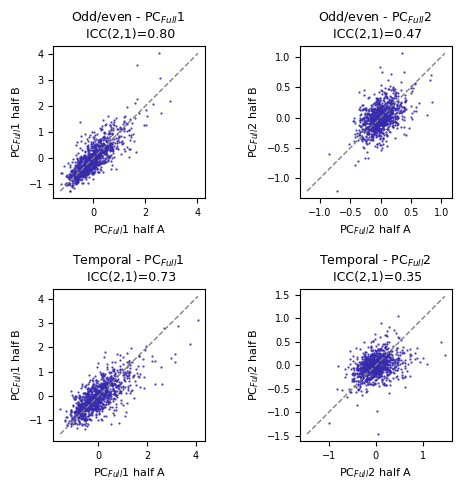

In [15]:
import matplotlib.pyplot as plt
import numpy as np

res_oe = split_half_pca_reliability(
    blup_A_odd_even, blup_B_odd_even, G=final_model.G[0],
    G_A=model_A_result_odd_even.G[0], G_B=model_B_result_odd_even.G[0],
    n_components=2, verbose=False,
)
res_tm = split_half_pca_reliability(
    blup_A_temporal, blup_B_temporal, G=final_model.G[0],
    G_A=model_A_result_temporal.G[0], G_B=model_B_result_temporal.G[0],
    n_components=2, verbose=False,
)

splits = [("Odd/even", res_oe), ("Temporal", res_tm)]
pcs = ["PC1", "PC2"]

fig, axes = plt.subplots(2, 2, figsize=(5, 5))
for i, (name, res) in enumerate(splits):
    s = res["scores"]
    rel = res["reliability"].set_index("axis")
    for j, pc in enumerate(pcs):
        ax = axes[i, j]
        a, b = s[f"{pc}_A"], s[f"{pc}_B"]

        sns.scatterplot(
            x=a, y=b, s=2, ax=ax,
            alpha=0.9, color="#372AAC", edgecolor=None
        )

        lo = min(a.min(), b.min())
        hi = max(a.max(), b.max())
        ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1)
        ax.set_aspect("equal", "box")

        r = rel.loc[pc, "ICC(A,1)"]

        # Display label: \mathrm{PC}_1 or \mathrm{PC}_2
        pc_label = rf"$\mathrm{{PC}}_{{Full}}{pc[-1]}$"

        ax.set_title(f"{name} - {pc_label} \n ICC(2,1)={r:.2f}", fontsize=9)
        ax.set_xlabel(f"{pc_label} half A", fontsize=8)
        ax.set_ylabel(f"{pc_label} half B", fontsize=8)
        ax.tick_params(axis='both', which='major', labelsize=7)

fig.tight_layout()

plt.savefig(
    FIGURES_DIR / "panel_3_PC1_PC2_split_half.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()